# Statistical Tests Practice Dataset



In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 120

df = pd.DataFrame({
    # ID
    "student_id": range(1, n + 1),

    # 2 independent groups → t-test / Mann-Whitney
    "gender": np.random.choice(["Male", "Female"], n),

    # 3+ independent groups → ANOVA / Kruskal
    "teaching_method": np.random.choice(["Online", "Classroom", "Hybrid"], n),

    # category vs category → Chi-square
    "passed": np.random.choice(["Pass", "Fail"], n, p=[0.75, 0.25]),

    # normally distributed numeric
    "exam_score": np.random.normal(75, 10, n).round(2),

    # another normal numeric
    "study_hours": np.random.normal(4, 1.2, n).round(2),

    # skewed numeric
    "screen_time": np.random.exponential(scale=3, size=n).round(2),

    # another skewed numeric
    "stress_level": np.random.gamma(shape=2, scale=2, size=n).round(2),

    # paired normal scores → paired t-test
    "pre_test_score": np.random.normal(60, 8, n).round(2),
})

# post-test related to pre-test
df["post_test_score"] = (df["pre_test_score"] + np.random.normal(8, 5, n)).round(2)

# paired non-normal scores → Wilcoxon
df["sleep_before"] = np.random.exponential(scale=5, size=n).round(2)
df["sleep_after"] = (df["sleep_before"] + np.random.exponential(scale=1.5, size=n)).round(2)

# repeated 3+ measures → Friedman
df["motivation_week1"] = np.random.exponential(scale=3, size=n).round(2)
df["motivation_week2"] = (df["motivation_week1"] + np.random.exponential(scale=1, size=n)).round(2)
df["motivation_week3"] = (df["motivation_week2"] + np.random.exponential(scale=1, size=n)).round(2)

# keep values realistic
df["exam_score"] = df["exam_score"].clip(0, 100)
df["pre_test_score"] = df["pre_test_score"].clip(0, 100)
df["post_test_score"] = df["post_test_score"].clip(0, 100)
df["study_hours"] = df["study_hours"].clip(0, None)

df.head()

,student_id,gender,teaching_method,passed,exam_score,study_hours,screen_time,stress_level,pre_test_score,post_test_score,sleep_before,sleep_after,motivation_week1,motivation_week2,motivation_week3
0,1,Male,Online,Fail,75.58,4.39,5.95,4.05,64.14,69.08,1.39,2.24,3.13,3.64,6.85
1,2,Female,Classroom,Pass,63.57,3.84,8.96,1.50,54.19,60.25,21.59,22.02,6.85,7.02,7.69
2,3,Male,Hybrid,Pass,78.58,4.12,0.48,3.17,61.49,70.92,0.77,2.21,0.84,5.73,5.85
3,4,Male,Online,Pass,80.61,4.71,7.83,1.08,53.96,63.63,3.45,5.29,7.85,10.47,11.26
4,5,Male,Classroom,Pass,85.83,3.02,2.03,1.57,55.11,66.40,4.81,5.08,0.19,0.97,1.58


## Do male and female students differ in their exam scores? 

Start with checking the normality of exam_score separately inside Male and Female groups.

In [2]:
from scipy.stats import shapiro

male_scores = df[df["gender"] == "Male"]["exam_score"]
female_scores = df[df["gender"] == "Female"]["exam_score"]

print("Male normality:")
print(shapiro(male_scores))

print("Female normality:")
print(shapiro(female_scores))

Male normality:
ShapiroResult(statistic=0.9833398858311816, pvalue=0.6985685280437189)
Female normality:
ShapiroResult(statistic=0.98408123009631, pvalue=0.5176695560663594)


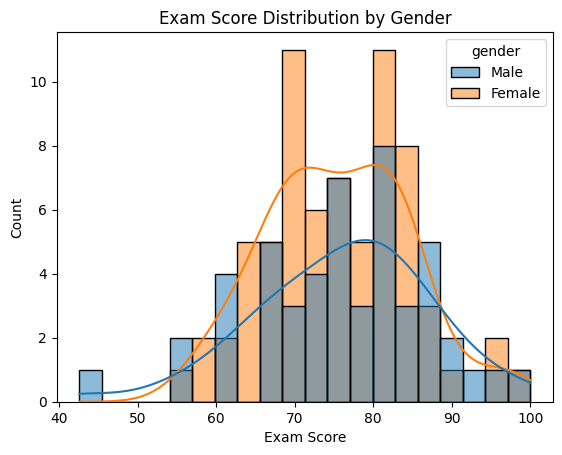

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Histogram + KDE: exam_score distribution by gender
sns.histplot(
    data=df,
    x="exam_score",
    hue="gender",
    kde=True,
    bins=20
)

plt.title("Exam Score Distribution by Gender")
plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.show()

[Scipy Stats Levene test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.levene.html)  

[Levene's test Test for variance equality Youtube](https://www.youtube.com/watch?v=x51GDTiPIfI)


In [4]:

from scipy.stats import levene

male_scores = df.loc[df["gender"] == "Male", "exam_score"]
female_scores = df.loc[df["gender"] == "Female", "exam_score"]

lev_stat, lev_p = levene(
    male_scores,
    female_scores,
    center="median",      # more robust than mean
    nan_policy="omit"
)

print(f"Levene statistic: {lev_stat:.4f}")
print(f"Levene p-value: {lev_p:.4f}")

if lev_p > 0.05:
    print("Variances are similar → use t-test with equal_var=True")
else:
    print("Variances are different → use Welch t-test with equal_var=False")

Levene statistic: 0.9457
Levene p-value: 0.3328
Variances are similar → use t-test with equal_var=True


[SciPy documentation t-test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html#scipy.stats.ttest_ind)

[YOUTUBE t-Test Explained Simply: What It Is, When to Use It, and How to Read the Results
](https://www.youtube.com/watch?v=a9liXroJyPg)

In [5]:
from scipy.stats import ttest_ind

# split groups
male_scores = df.loc[df["gender"] == "Male", "exam_score"]
female_scores = df.loc[df["gender"] == "Female", "exam_score"]

# independent t-test
t_stat, p_value = ttest_ind(
    male_scores,
    female_scores,
    equal_var=True,          # True = classic Student t-test
    nan_policy="omit",       # ignores missing values if any
    alternative="two-sided"  # checks difference in both directions
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Significant difference between male and female exam scores.")
else:
    print("Result: No significant difference between male and female exam scores.")

T-statistic: 0.2800
P-value: 0.7800
Result: No significant difference between male and female exam scores.


**Do students using Online, Classroom, and Hybrid teaching methods differ in their mean exam scores?**

In [7]:
df["teaching_method"].value_counts()

teaching_method
Online       46
Hybrid       45
Classroom    29
Name: count, dtype: int64

In [6]:
from scipy.stats import shapiro

for method in df["teaching_method"].unique():
    scores = df.loc[df["teaching_method"] == method, "exam_score"]
    
    stat, p = shapiro(scores)
    
    print(f"{method}")
    print(f"Shapiro statistic: {stat:.4f}")
    print(f"p-value: {p:.4f}")
    
    if p > 0.05:
        print("Normal\n")
    else:
        print("Not normal\n")

Online
Shapiro statistic: 0.9656
p-value: 0.1895
Normal

Classroom
Shapiro statistic: 0.9800
p-value: 0.8387
Normal

Hybrid
Shapiro statistic: 0.9922
p-value: 0.9892
Normal



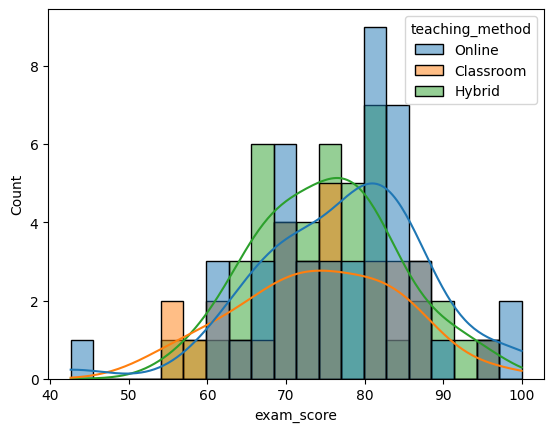

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=df,
    x="exam_score",
    hue="teaching_method",
    kde=True,
    bins=20
)

plt.show()



In [9]:
online = df.loc[df["teaching_method"] == "Online", "exam_score"]
classroom = df.loc[df["teaching_method"] == "Classroom", "exam_score"]
hybrid = df.loc[df["teaching_method"] == "Hybrid", "exam_score"]

The ANOVA test has important assumptions that must be satisfied in order for the associated p-value to be valid.

The samples are independent. Well they are, 3 independent samples

Each sample is from a normally distributed population. - Shapiro Wilk confirmed

The population standard deviations of the groups are all equal. This property is known as homoscedasticity. -  Levene test below ↓

In [10]:
from scipy.stats import levene
lev_stat, lev_p = levene(
    online,
    classroom,
    hybrid,
    center="median",
    nan_policy="omit"
)

print(f"Levene statistic: {lev_stat:.4f}")
print(f"Levene p-value: {lev_p:.4f}")

if lev_p > 0.05:
    print("Variances are similar → ANOVA is okay")
else:
    print("Variances are different → consider Welch ANOVA")

Levene statistic: 0.3515
Levene p-value: 0.7044
Variances are similar → ANOVA is okay


In [11]:
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(
    online,
    classroom,
    hybrid
)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Significant mean difference between teaching methods.")
else:
    print("Result: No significant mean difference between teaching methods.")

F-statistic: 1.0311
P-value: 0.3598
Result: No significant mean difference between teaching methods.


**Is there an association between teaching method and pass/fail status?**

In [12]:
print(df.teaching_method.value_counts())
print(df.passed.value_counts())

teaching_method
Online       46
Hybrid       45
Classroom    29
Name: count, dtype: int64
passed
Pass    92
Fail    28
Name: count, dtype: int64


Use a Chi-square test when analyzing categorical data to determine if observed frequencies differ significantly from expected frequencies. It is primarily used to test for relationships between two categorical variables (independence) or to compare observed distributions against a theoretical model (goodness-of-fit

Variable 1 = teaching_method → Online, Classroom, Hybrid

Variable 2 = passed          → Pass, Fail

[SciPy chi2_contingency documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html)

In [15]:
import pandas as pd
from scipy.stats import chi2_contingency

ct = pd.crosstab(df["teaching_method"], df["passed"])

chi_stat, p_value, dof, expected = chi2_contingency(ct)

expected_df = pd.DataFrame(
    expected,
    index=ct.index,
    columns=ct.columns
)

print("Observed counts:")
print(ct)

print("\nExpected counts:")
print(expected_df.round(2))

print(f"\nMinimum expected count: {expected.min():.2f}")

Observed counts:
passed           Fail  Pass
teaching_method            
Classroom           8    21
Hybrid             11    34
Online              9    37

Expected counts:
passed            Fail   Pass
teaching_method              
Classroom         6.77  22.23
Hybrid           10.50  34.50
Online           10.73  35.27

Minimum expected count: 6.77


In [16]:
from scipy.stats import chi2_contingency

chi2_stat, p_value, dof, expected = chi2_contingency(ct)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("Result: Significant association between teaching method and pass/fail status.")
else:
    print("Result: No significant association between teaching method and pass/fail status.")

Chi-square statistic: 0.6894
P-value: 0.7084
Degrees of freedom: 2
Result: No significant association between teaching method and pass/fail status.
